In [1]:
# Silence warnings
import warnings
warnings.filterwarnings("ignore")

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("fetal_health.csv")

print("Shape:", df.shape)
df.head()

Shape: (2126, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [4]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [5]:
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [6]:
df.duplicated().sum()

13

In [7]:
df = df.drop_duplicates()
print(df.shape)

(2113, 22)


In [8]:
df["fetal_health"].value_counts()

fetal_health
1.0    1646
2.0     292
3.0     175
Name: count, dtype: int64

In [9]:
df["fetal_health"].value_counts(normalize=True)

fetal_health
1.0    0.778987
2.0    0.138192
3.0    0.082821
Name: proportion, dtype: float64

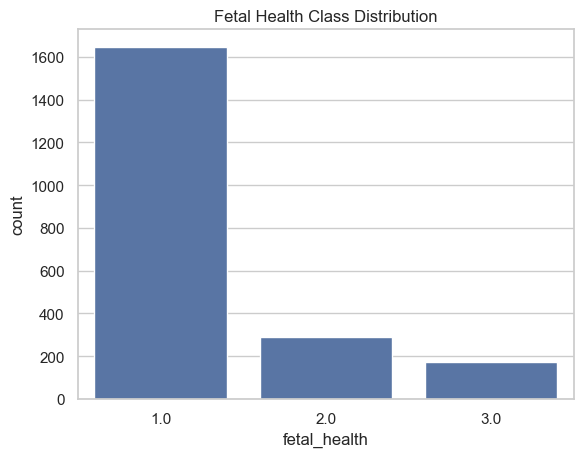

In [10]:
sns.countplot(x="fetal_health", data=df)
plt.title("Fetal Health Class Distribution")
plt.show()

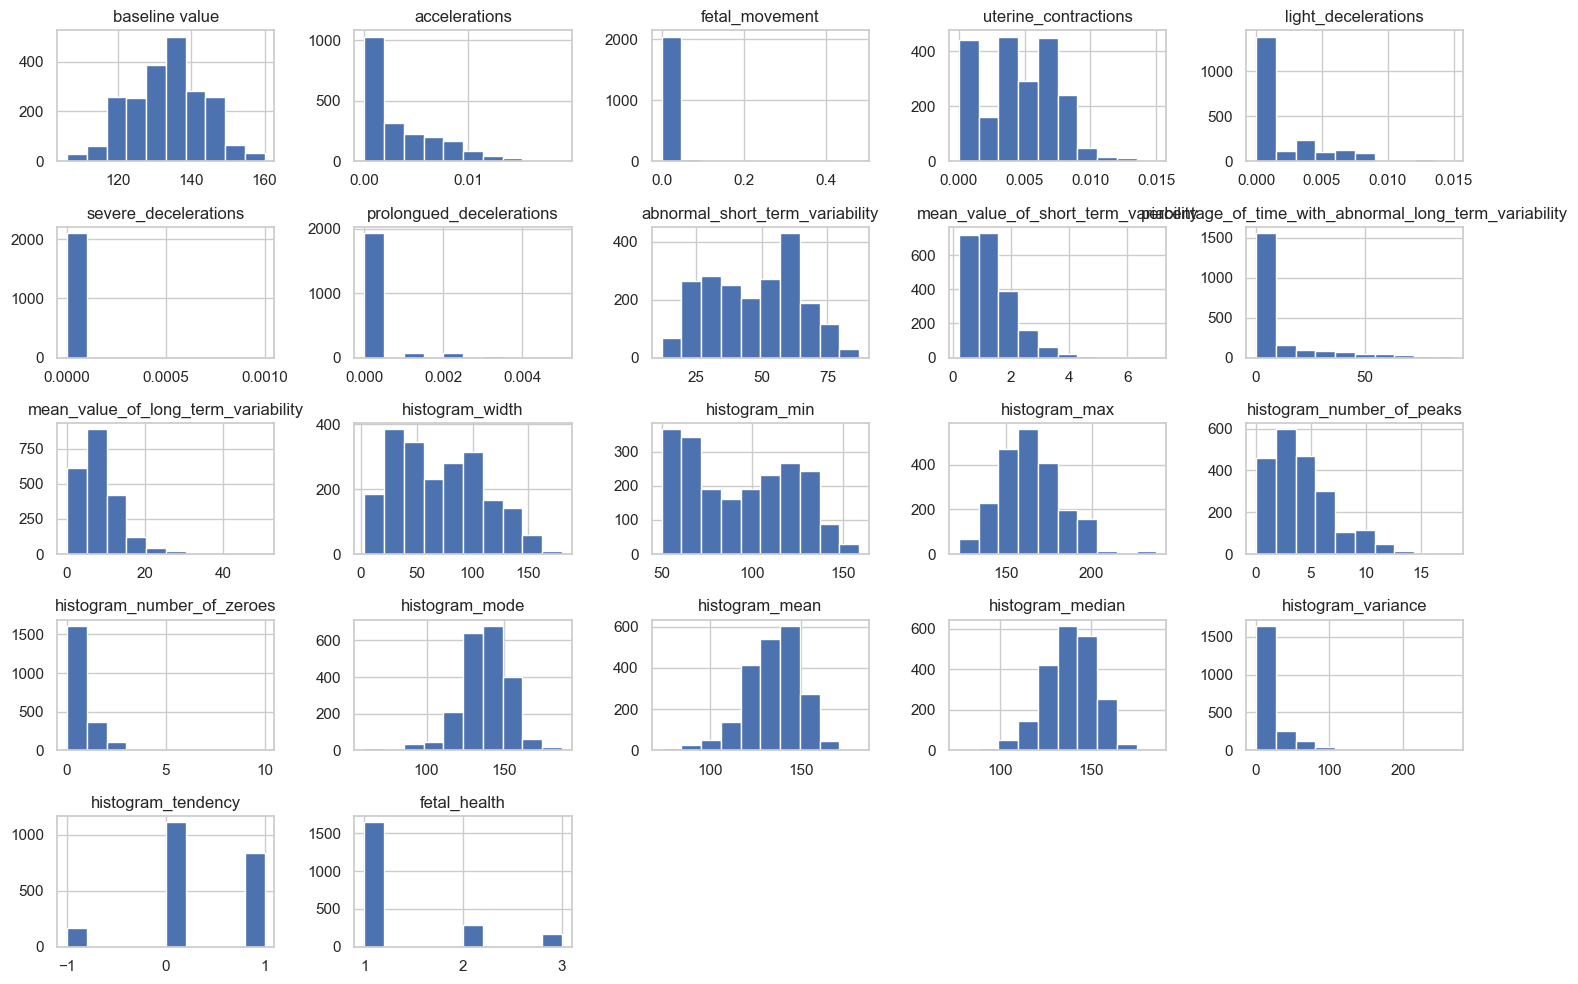

In [11]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

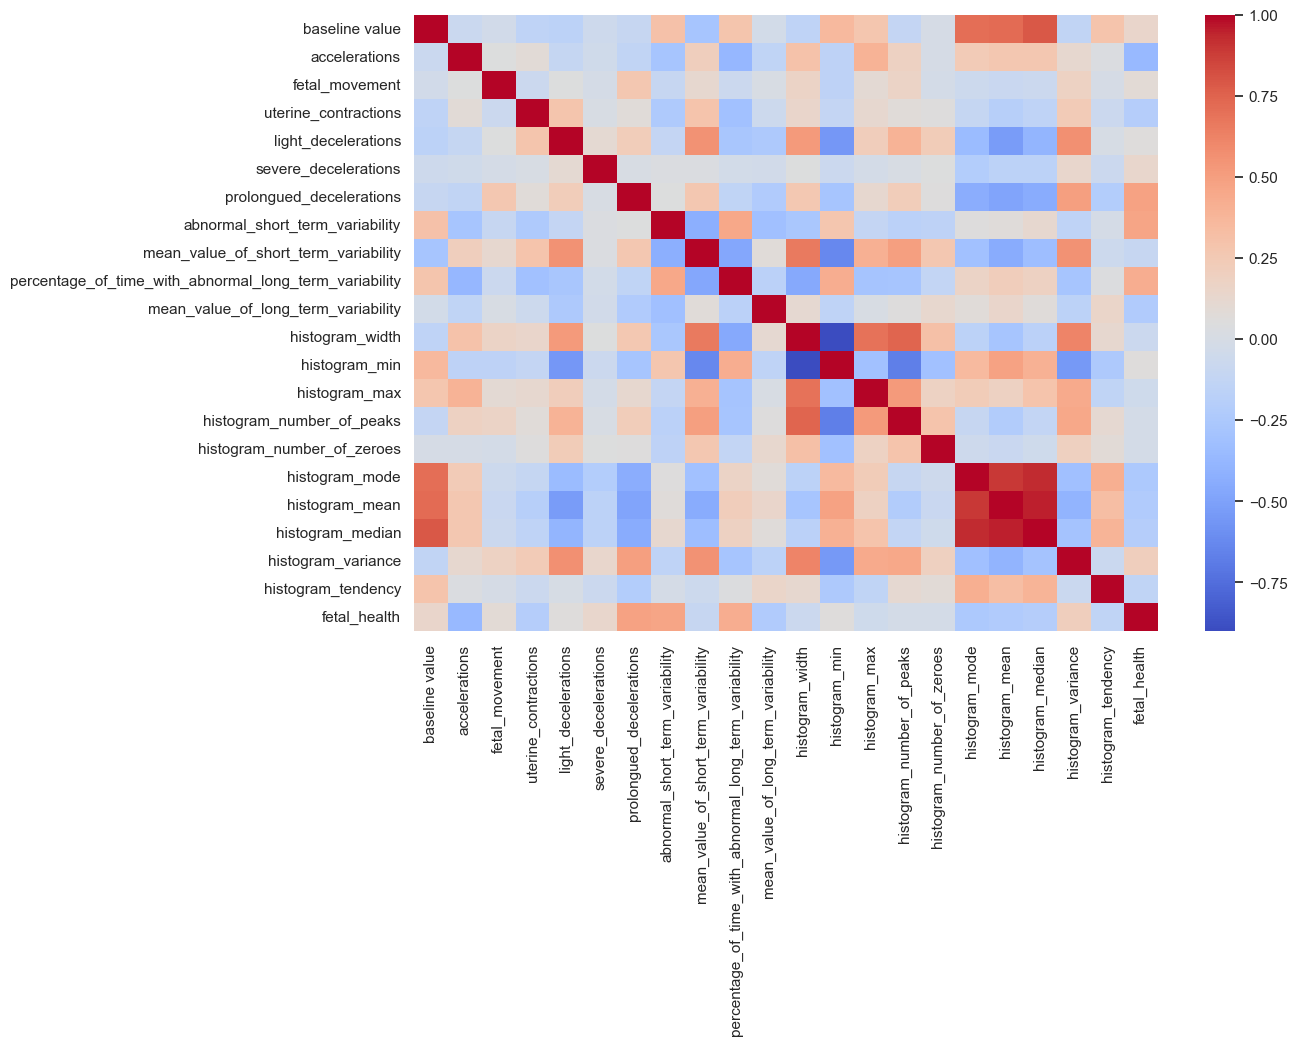

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [13]:
# Features (X) and target (y)
X = df.drop(columns=["fetal_health"])
y = df["fetal_health"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2113, 21)
y shape: (2113,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT for class balance
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1690, 21)
Test shape: (423, 21)


In [15]:
num_features = X.columns.tolist()
print("Number of features:", len(num_features))

Number of features: 21


In [16]:
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [17]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features)
])

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (1690, 21)
Processed test shape: (423, 21)


In [19]:
print("Mean (approx):", X_train_processed.mean())
print("Std (approx):", X_train_processed.std())

Mean (approx): 2.7528776040296923e-17
Std (approx): 1.0


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Baseline model pipelines
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation F1 (macro is better for multiclass balance)
log_f1 = cross_val_score(log_model, X_train, y_train, cv=cv, scoring="f1_macro")
tree_f1 = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring="f1_macro")

print("Logistic Regression CV F1-macro:", log_f1.mean())
print("Decision Tree CV F1-macro:", tree_f1.mean())

Logistic Regression CV F1-macro: 0.7791269898393478
Decision Tree CV F1-macro: 0.8549547448281032


In [21]:
# Train baseline models
log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

In [22]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Classification Report
              precision    recall  f1-score   support

         1.0       0.92      0.96      0.94       330
         2.0       0.64      0.55      0.59        58
         3.0       0.90      0.77      0.83        35

    accuracy                           0.89       423
   macro avg       0.82      0.76      0.79       423
weighted avg       0.88      0.89      0.88       423

Decision Tree Classification Report
              precision    recall  f1-score   support

         1.0       0.96      0.97      0.96       330
         2.0       0.80      0.76      0.78        58
         3.0       0.94      0.89      0.91        35

    accuracy                           0.93       423
   macro avg       0.90      0.87      0.88       423
weighted avg       0.93      0.93      0.93       423



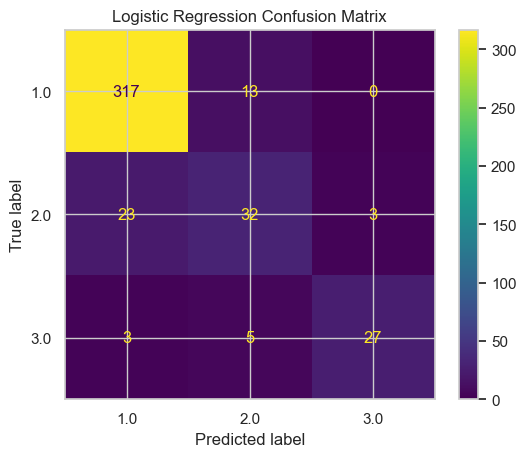

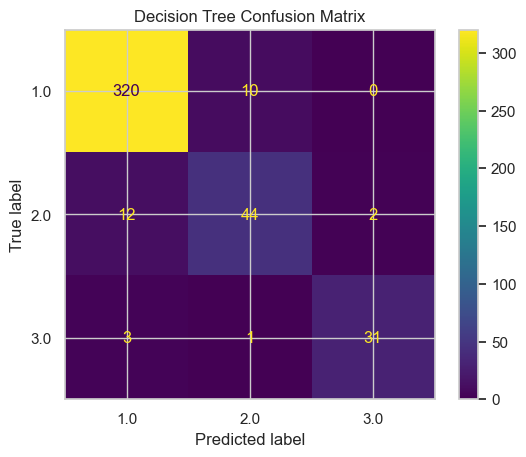

In [23]:
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_estimator(tree_model, X_test, y_test)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [25]:
rf_f1 = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="f1_macro")

print("Random Forest CV F1:", rf_f1.mean())

Random Forest CV F1: 0.8814535870313792


In [26]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:

              precision    recall  f1-score   support

         1.0       0.95      0.99      0.97       330
         2.0       0.93      0.72      0.82        58
         3.0       0.97      0.91      0.94        35

    accuracy                           0.95       423
   macro avg       0.95      0.88      0.91       423
weighted avg       0.95      0.95      0.95       423



In [27]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Train Accuracy: 0.9988165680473373
Test Accuracy: 0.950354609929078


In [28]:
param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [30]:
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the var

In [31]:
print("Best Parameters:", rf_search.best_params_)

Best Parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}


In [32]:
best_rf = rf_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("Tuned Random Forest Report:\n")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Report:

              precision    recall  f1-score   support

         1.0       0.95      0.99      0.97       330
         2.0       0.91      0.67      0.77        58
         3.0       0.97      0.91      0.94        35

    accuracy                           0.94       423
   macro avg       0.94      0.86      0.89       423
weighted avg       0.94      0.94      0.94       423



In [33]:
train_score_tuned = best_rf.score(X_train, y_train)
test_score_tuned = best_rf.score(X_test, y_test)

print("Tuned Train Accuracy:", train_score_tuned)
print("Tuned Test Accuracy:", test_score_tuned)
print("Gap:", train_score_tuned - test_score_tuned)

Tuned Train Accuracy: 0.9816568047337279
Tuned Test Accuracy: 0.9432624113475178
Gap: 0.03839439338621009


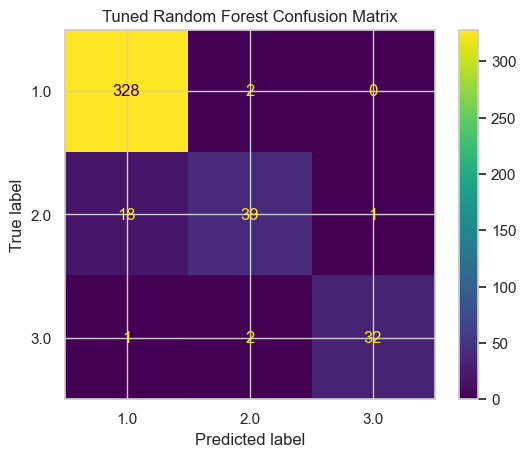

In [34]:
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [35]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Tuned Random Forest"],
    "CV F1 Macro": [
        log_f1.mean(),
        tree_f1.mean(),
        rf_f1.mean(),
        rf_search.best_score_
    ],
    "Test Accuracy": [
        log_model.score(X_test, y_test),
        tree_model.score(X_test, y_test),
        rf_model.score(X_test, y_test),
        best_rf.score(X_test, y_test)
    ]
})

results

,Model,CV F1 Macro,Test Accuracy
0,Logistic Regression,0.779127,0.888889
1,Decision Tree,0.854955,0.933806
2,Random Forest,0.881454,0.950355
3,Tuned Random Forest,0.883731,0.943262


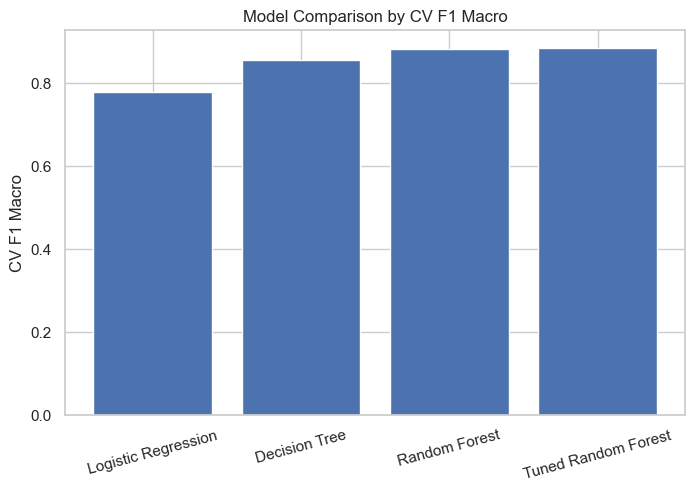

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["CV F1 Macro"])
plt.title("Model Comparison by CV F1 Macro")
plt.ylabel("CV F1 Macro")
plt.xticks(rotation=15)
plt.show()

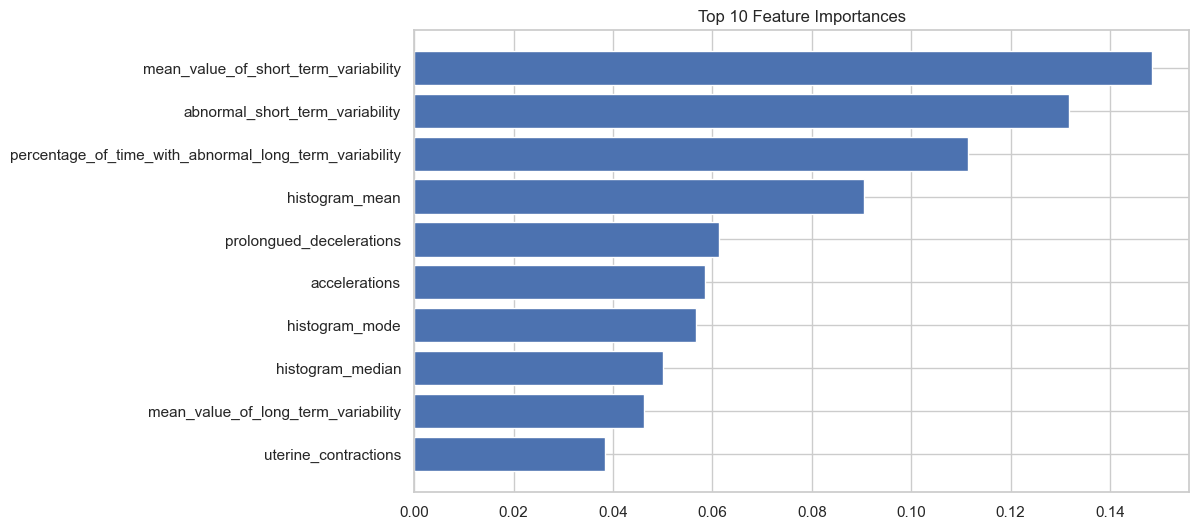

In [37]:
import pandas as pd

# Extract feature importance
feature_importance = best_rf.named_steps["classifier"].feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

In [38]:
import joblib

In [39]:
joblib.dump(best_rf, "model.pkl")

['model.pkl']

In [40]:
import os
print(os.listdir())

['.anaconda', '.android', '.cache', '.conda', '.condarc', '.continuum', '.dotnet', '.eclipse', '.emulator_console_auth_token', '.gradle', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.m2', '.matplotlib', '.nuget', '.p2', '.packettracer', '.ssh', '.streamlit', '.VirtualBox', '.virtual_documents', '.vscode', '01_plan_view.png', '02_cross_section.png', '03_longitudinal_profile.png', '04_drainage_layout.png', '05_lane_markings.png', '06_services_offset.png', '1766306850_providers_all_time.csv', '3D Objects', 'ABC_Project_Cost_and_NPV.xlsx', 'accounting_data.xlsx', 'accounting_records.xlsx', 'adjusted_accounting_records.xlsx', 'AMDRM_Install.log', 'anaconda3', 'analysis_outputs', 'AndroidStudioProjects', 'ansel', 'app.py', 'AppData', 'Application Data', 'BD_200_Hospital_Facility_Dataset (1).xlsx', 'BD_200_Hospital_Facility_Dataset_GEO_FILLED_OSM.xlsx', 'Bridge_Elevation.ipynb', 'Cisco Packet Tracer 8.2.2', 'Community Garden Resource Management System.ipynb', 'Contacts', 'Cookies

In [41]:
import os
print(os.getcwd())

C:\Users\User


In [42]:
os.listdir()

['.anaconda',
 '.android',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.dotnet',
 '.eclipse',
 '.emulator_console_auth_token',
 '.gradle',
 '.ipynb_checkpoints',
 '.ipython',
 '.junie',
 '.jupyter',
 '.m2',
 '.matplotlib',
 '.nuget',
 '.p2',
 '.packettracer',
 '.ssh',
 '.streamlit',
 '.VirtualBox',
 '.virtual_documents',
 '.vscode',
 '01_plan_view.png',
 '02_cross_section.png',
 '03_longitudinal_profile.png',
 '04_drainage_layout.png',
 '05_lane_markings.png',
 '06_services_offset.png',
 '1766306850_providers_all_time.csv',
 '3D Objects',
 'ABC_Project_Cost_and_NPV.xlsx',
 'accounting_data.xlsx',
 'accounting_records.xlsx',
 'adjusted_accounting_records.xlsx',
 'AMDRM_Install.log',
 'anaconda3',
 'analysis_outputs',
 'AndroidStudioProjects',
 'ansel',
 'app.py',
 'AppData',
 'Application Data',
 'BD_200_Hospital_Facility_Dataset (1).xlsx',
 'BD_200_Hospital_Facility_Dataset_GEO_FILLED_OSM.xlsx',
 'Bridge_Elevation.ipynb',
 'Cisco Packet Tracer 8.2.2',
 'Community Garden Resourc

In [43]:
import joblib
joblib.dump(best_rf, "model.pkl")

['model.pkl']

In [44]:
import joblib
joblib.dump(best_rf, "model.pkl")

['model.pkl']